**Problem Statement**

Customer Personality Analysis project aims to perform a detailed analysis of a compnay's ideal customers which in return helps a business to better undertand its Customers and make it easier for the company to modify the products branding and reach according to the specific needs, beaviours, and concerns of different types of customers.
For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

# **Content**
**Attributes**

**People**

*   ID: Customer's unique identifier
*   Year_Birth: Customer's birth year
*   Education: Customer's education level
*   Marital_Status: Customer's marital status
*   Income: Customer's yearly household income
*   Kidhome: Number of children in customer's household
*   Teenhome: Number of teenagers in customer's household
*   Dt_Customer: Date of customer's enrollment with the company
*   Recency: Number of days since customer's last purchase
*   Complain: 1 if the customer complained in the last 2 years, 0 otherwise


**Products**

- MntWines: Amount spent on wine in last 2 years
- MntFruits: Amount spent on fruits in last 2 years
- MntMeatProducts: Amount spent on meat in last 2 years
- MntFishProducts: Amount spent on fish in last 2 years
- MntSweetProducts: Amount spent on sweets in last 2 years
- MntGoldProds: Amount spent on gold in last 2 years

**Promotion**

- NumDealsPurchases: Number of purchases made with a discount
- AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

**Place**

- NumWebPurchases: Number of purchases made through the company’s website
- NumCatalogPurchases: Number of purchases made using a catalogue
- NumStorePurchases: Number of purchases made directly in stores
- NumWebVisitsMonth: Number of visits to company’s website in the last month

**Target**

Need to perform clustering to summarize customer segments.

*Acknowledgement*

*The dataset for this project is provided by Dr. Omar Romero-Hernandez.*

In [ ]:
# Importing all the libraries
import numpy as np
import pandas as pd
import datetime
from datetime import date
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler, normalize
from sklearn import metrics
from sklearn.mixture import GaussianMixture
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings
warnings.filterwarnings('ignore')
data=pd.read_csv('marketing_campaign.csv',header=0,sep='\t')

In [ ]:
data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
## Removing ID from the data since it serves no purpose
data.drop(columns=['ID'], inplace=True)

In [ ]:
## Dataset description. To gain insights on the data
def descrb():
  print(f'Data description \n {data.describe()}')
  print(f'Any null rows for any columns? \n {data.isna().sum()}')
  print(f'Dataframe Information \n {data.info()}')
descrb()

Data description 
         Year_Birth         Income      Kidhome     Teenhome      Recency  \
count  2240.000000    2216.000000  2240.000000  2240.000000  2240.000000   
mean   1968.805804   52247.251354     0.444196     0.506250    49.109375   
std      11.984069   25173.076661     0.538398     0.544538    28.962453   
min    1893.000000    1730.000000     0.000000     0.000000     0.000000   
25%    1959.000000   35303.000000     0.000000     0.000000    24.000000   
50%    1970.000000   51381.500000     0.000000     0.000000    49.000000   
75%    1977.000000   68522.000000     1.000000     1.000000    74.000000   
max    1996.000000  666666.000000     2.000000     2.000000    99.000000   

          MntWines    MntFruits  MntMeatProducts  MntFishProducts  \
count  2240.000000  2240.000000      2240.000000      2240.000000   
mean    303.935714    26.302232       166.950000        37.525446   
std     336.597393    39.773434       225.715373        54.628979   
min       0.000000  

In [ ]:
## Removing NaN values from the dataset as it is less than 2%
data.dropna(axis=0, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2216 non-null   int64  
 1   Education            2216 non-null   object 
 2   Marital_Status       2216 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Dt_Customer          2216 non-null   object 
 7   Recency              2216 non-null   int64  
 8   MntWines             2216 non-null   int64  
 9   MntFruits            2216 non-null   int64  
 10  MntMeatProducts      2216 non-null   int64  
 11  MntFishProducts      2216 non-null   int64  
 12  MntSweetProducts     2216 non-null   int64  
 13  MntGoldProds         2216 non-null   int64  
 14  NumDealsPurchases    2216 non-null   int64  
 15  NumWebPurchases      2216 non-null   int64 

In order to gain deeper insights on data, let us use visualizations

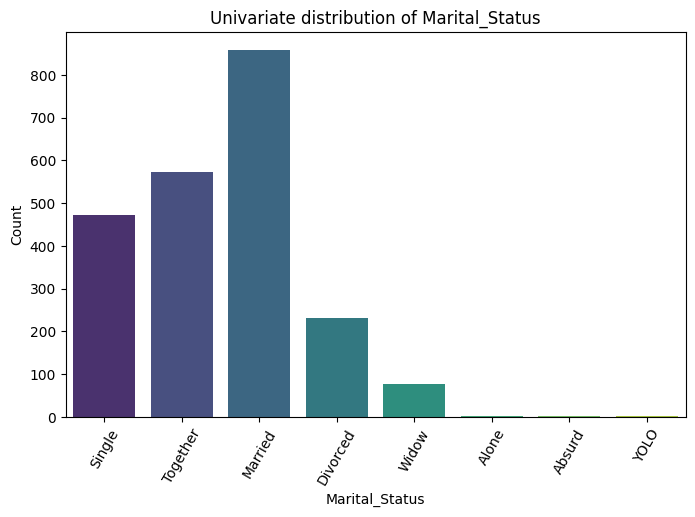

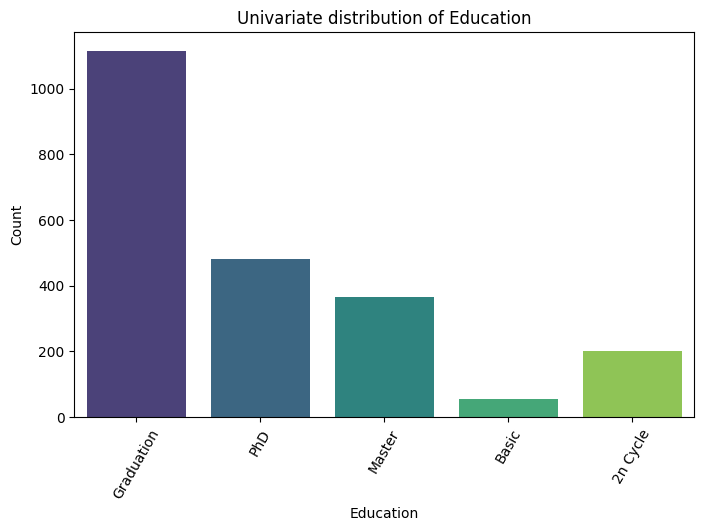

In [ ]:
# Histplots on all the numerical features to understand the distributions
# Visualize categorical variables, In or case - Marital Status, Education
cat_col = ['Marital_Status', 'Education']
for i in cat_col:
  plt.figure(figsize=(8,5))
  sns.countplot(data=data[cat_col], x=i, palette='viridis')
  plt.title(f'Univariate distribution of {i}')
  plt.xlabel(i)
  plt.xticks(rotation=60)
  plt.ylabel('Count')
  plt.show()

looking at the visualization, we find that the majority of the customer in the dataset have atleast a graduate degree and that they are married. we see that there are very few odd values in Marital_status --> 'Alone', 'Absurd', 'Yolo'. We can remove 'Alone', 'Abusrd', and 'Yolo' from the dataset as

a. it doesn't serve any purpose

b. It's occurance is insignificant

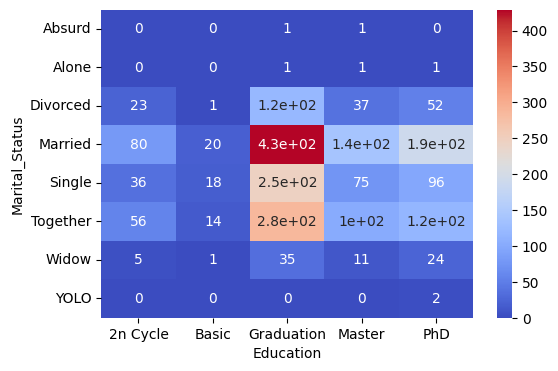

In [ ]:
# sns.heatmap(data[['Marital_Status','Education']], cmap='coolwarm', annot=True)
pivot_table = pd.crosstab(data['Marital_Status'], data['Education'])
plt.figure(figsize=(6,4))
sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt='.2g')
plt.show()

We can see in the above diagram that most of the Married, Single, and Together Customer do seem to have Graduation degree. However, this could also because There are majority of customers having Graduation degree. So, we cannot jump into conclusion that Married status and Graduation degree is inter dependent.

In [ ]:
#Removing the unnecessary value in Marital_status
data["Marital_Status"] = data["Marital_Status"].replace('Alone', 'Single')
data = data[~data['Marital_Status'].isin(['Absurd', 'YOLO'])]
data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,474
Divorced,232
Widow,76


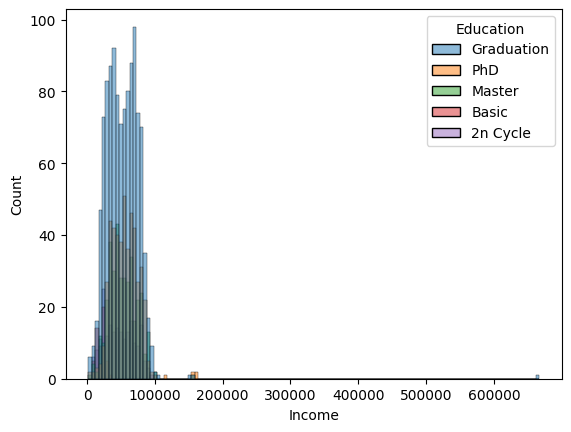

In [ ]:
sns.histplot(data=data, x='Income', hue='Education', bins='auto')
plt.show()

Income is an important feature to be used for customer segmentation. Upon looking at the Income distribution, we can definitely see some outliers. We need to take care of that.

In [ ]:
# Using IQR to remove outliers (anything below .25 and anything above .75 quantiles are considered outliers.)
Q1 = data['Income'].quantile(0.25)
Q3 = data['Income'].quantile(0.75)
IQR = Q3 - Q1
lowerbound = Q1 -1.5 * IQR
upperbound = Q3 +1.5 * IQR
data = data[(data['Income']>=lowerbound) & (data['Income']<=upperbound)]


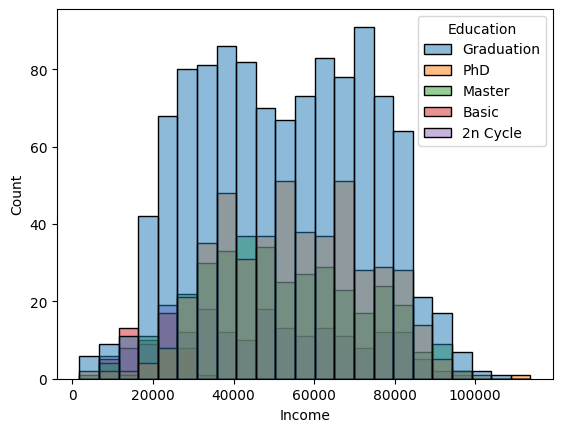

In [ ]:
#After removing the outliers, this is how the Income distribution looks
sns.histplot(data=data, x='Income', hue='Education', bins='auto')
plt.show()

Now we will create and manage features with the aim to be close to resolving our domain specific problem.

In [ ]:
data['Age'] = 2025 - data['Year_Birth']
# After creating the age features, we can see there are some outliers
# So, we are going to remove the outliers by accepting age less than 90.
data = data[data['Age']<=90]
data['Age'].describe()

,Age
count,2201.000000
mean,56.104952
std,11.701763
min,29.000000
25%,48.000000
50%,55.000000
75%,66.000000
max,85.000000


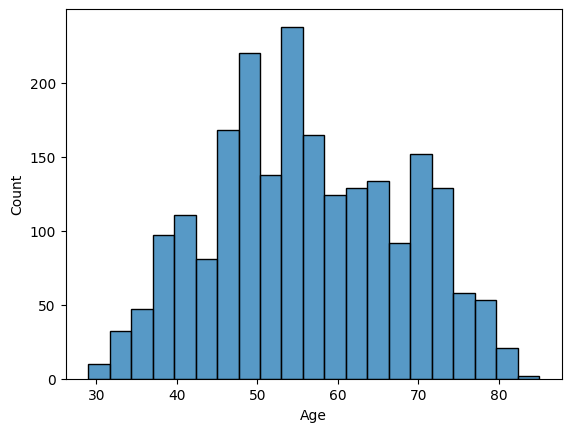

In [ ]:
sns.histplot(data=data, x='Age', bins='auto')
plt.show()

In [ ]:
# Total spending variable creation
data['Total_Spending'] = data['MntWines']+data['MntFruits']+data['MntMeatProducts']+data['MntFishProducts']+data['MntSweetProducts']+data['MntGoldProds']
# Seniority variable creation, Seniority is measured in terms of months
last_date = date(2024,10,4)
data['Seniority'] = pd.to_datetime(data['Dt_Customer'], dayfirst=True, format='%d-%m-%Y')
data['Seniority'] = pd.to_numeric(data['Seniority'].dt.date.apply(lambda x: (last_date - x)).dt.days, downcast='integer')/30
data = data.rename(columns={'NumWebPurchases': "Web",'NumCatalogPurchases':'Catalog','NumStorePurchases':'Store'})

data['Marital_Status']= data['Marital_Status'].replace({'Divorced':'Alone','Single':'Alone','Married':'couple','Together':'couple','Widow':'Alone'})

data['Education']= data['Education'].replace({'Basic':'Undergraduate','2n Cycle':'Undergraduate','Graduation':'Postgraduate','Master':'Postgraduate','PhD':'Postgraduate'})

data['Children'] = data['Kidhome'] + data['Teenhome']

data['has_child'] = np.where(data.Children > 0, 'Has Child', 'No Child')

data['Children'].replace({3: "3 children",2:'2 children',1:'1 child',0:"No child"},inplace=True)

data=data.rename(columns={'MntWines': "Wines",'MntFruits':'Fruits','MntMeatProducts':'Meat','MntFishProducts':'Fish','MntSweetProducts':'Sweets','MntGoldProds':'Gold'})
data_segment=data[['Age','Education','Marital_Status','Income','Total_Spending','Seniority','has_child','Children','Wines','Fruits','Meat','Fish','Sweets','Gold']]
data_segment.head()

,Age,Education,Marital_Status,Income,Total_Spending,Seniority,has_child,Children,Wines,Fruits,Meat,Fish,Sweets,Gold
0,68,Postgraduate,Alone,58138.0,1617,147.100000,No Child,No child,635,88,546,172,88,88
1,71,Postgraduate,Alone,46344.0,27,128.766667,Has Child,2 children,11,1,6,2,1,6
2,60,Postgraduate,couple,71613.0,776,135.400000,No Child,No child,426,49,127,111,21,42
3,41,Postgraduate,couple,26646.0,53,129.633333,Has Child,1 child,11,4,20,10,3,5
4,44,Postgraduate,couple,58293.0,422,130.366667,Has Child,1 child,173,43,118,46,27,15


We are using two techniques to segment the customers in the dataset.


*   We can segment the customer based on the values we already have in the dataset, like - 'Income', 'Seniority', and 'Spending'. It could be insightful to segment customers based on these three values and have them labeled. So that we can build custom marketing strategies for each labels
*   We can also segment/cluster the customers using K-Means clustering algorithms

We are going to use both approach and see which one fits better.



Let us start with the first approach where we cluster the customers based on
'Income', 'Seniority', and 'Spending'

We will build 4 customer segments:


1.   **Stellars**: Old Customers with high income and high spending nature
2.   **RedDwarfs**: New customers with below-average income and low spending nature
3.   **YoungStellars**: New customers with high income and high spending nature
4.   **WhiteDwarfs**: Old customers with below-average income and low spending nature



In [ ]:
scaler=StandardScaler()
dataset_temp=data[['Income','Seniority','Total_Spending']]
X_std=scaler.fit_transform(dataset_temp)
X_norm = normalize(X_std,norm='l2')

In [ ]:
gmm=GaussianMixture(n_components=4, covariance_type='spherical',max_iter=2000, random_state=5).fit(X_norm)
labels = gmm.predict(X_norm)
dataset_temp['Cluster'] = labels

In [ ]:
df_a = dataset_temp.groupby('Cluster')[['Income', 'Seniority', 'Total_Spending']].mean().reset_index()

,Cluster,Income,Seniority,Total_Spending
0,0,69247.887218,142.763972,1242.657895
1,1,37775.026941,130.815848,121.922345
2,2,34441.509402,142.320228,186.528205
3,3,72319.918322,130.916630,1076.518764


We can see how the center of the data looks like. Using this insight we can see that if we consider Mean as our reference point (meaning anything above mean is high and below is low), we can see that by using gaussian mixture model, we have already clustered the data as per our initial requirement. So, we can just go ahead and label the cluster for more clarity and then use Plotting to visualize the data.

In [ ]:
dataset_temp = dataset_temp.replace({0:'Stellars',1:'RedDwarfs',2:'YoungStellars',3:'WhiteDwarfs'})
data = data.merge(dataset_temp.Cluster, left_index=True, right_index=True)

In [ ]:
dataset_temp.groupby('Cluster').describe().transpose()

Cluster                  RedDwarfs       Stellars    WhiteDwarfs  \
Income         count    631.000000     532.000000     453.000000   
               mean   37775.026941   69247.887218   72319.918322   
               std    12335.962164   11337.516092    9864.980199   
               min     1730.000000   44802.000000   49090.000000   
               25%    29122.500000   60674.500000   65196.000000   
               50%    38361.000000   68557.000000   71434.000000   
               75%    46900.500000   77665.500000   79419.000000   
               max    64587.000000  105471.000000  113734.000000   
Seniority      count    631.000000     532.000000     453.000000   
               mean     130.815848     142.763972     130.916630   
               std        3.396005       3.361517       3.363183   
               min      125.000000     135.566667     125.000000   
               25%      127.866667     139.950000     127.933333   
               50%      130.766667     142.766667     131.000000   
               75%      133.733333     145.766667     133.866667   
               max      137.033333     148.266667     137.300000   
Total_Spending count    631.000000     532.000000     453.000000   
               mean     121.922345    1242.657895    1076.518764   
               std      127.204555     442.251945     460.647292   
               min        6.000000     260.000000     227.000000   
               25%       39.000000     907.000000     757.000000   
               50%       65.000000    1187.500000    1033.000000   
               75%      162.500000    1541.000000    1378.000000   
               max      636.000000    2524.000000    2525.000000   

Cluster               YoungStellars  
Income         count     585.000000  
               mean    34441.509402  
               std     11956.715785  
               min      2447.000000  
               25%     26224.000000  
               50%     34968.000000  
               75%     42767.000000  
               max     60544.000000  
Seniority      count     585.000000  
               mean      142.320228  
               std         3.422201  
               min       135.933333  
               25%       139.433333  
               50%       142.300000  
               75%       145.266667  
               max       148.300000  
Total_Spending count     585.000000  
               mean      186.528205  
               std       187.066301  
               min         5.000000  
               25%        47.000000  
               50%       103.000000  
               75%       293.000000  
               max      1730.000000

In [ ]:
PLOT = go.Figure()
for C in list(data.Cluster.unique()):


    PLOT.add_trace(go.Scatter3d(x = data[data.Cluster == C]['Income'],
                                y = data[data.Cluster == C]['Seniority'],
                                z = data[data.Cluster == C]['Total_Spending'],
                                mode = 'markers',marker_size = 6, marker_line_width = 1,
                                name = str(C)))
PLOT.update_traces(hovertemplate='Income: %{x} <br>Seniority: %{y} <br>Spending: %{z}')


PLOT.update_layout(width = 800, height = 800, autosize = True, showlegend = True,
                   scene = dict(xaxis=dict(title = 'Income', titlefont_color = 'black'),
                                yaxis=dict(title = 'Seniority', titlefont_color = 'black'),
                                zaxis=dict(title = 'Spending', titlefont_color = 'black')),
                   font = dict(family = "Gilroy", color  = 'black', size = 12))

**Now, We try K-Means algorithm to segment the customers and then we can compare our results with the GMM.**